In [1]:
# 초기 1회 실행
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Lessong 3-7 Appendix

In [2]:
## 필요 패키지 설치 및 import
import importlib.util
import subprocess
import sys
def install_and_import(packages):
    for pkg in packages:
        package = pkg
        try:
            importlib.util.find_spec(package)
            print(f"{package} is already installed.")
        except ImportError:
            # 모듈이 설치되어 있지 않은 경우 설치시도
            print(f"{package} is not installed. Installing...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
            subprocess.check_call(["conda", "install", package, "-y"])

            # 설치 후 다시 임포트를 시도
            importlib.import_module(package)
            print(f"{package} has been successfully installed.")

        # finally:
        #     globals()[package] = importlib.import_module(package)
        except Exception as e:
            # 설치 중 예외가 발생한 경우, 에러 메시지를 출력
            print(f"An error occurred while installing {package}: {str(e)}")

# 예시 사용법
install_and_import(['mlxtend'])


mlxtend is already installed.


In [3]:
ppath = '/content/drive/MyDrive/5. STUDY_ETC/Metacode/lesson3'

## 데이터 로드

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import PowerTransformer
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [5]:
## 데이터 로드
train = pd.read_csv(ppath + "/1. data/kc_house_train_data.csv")
test = pd.read_csv(ppath + "/1. data/kc_house_test_data.csv")


## 데이터 준비


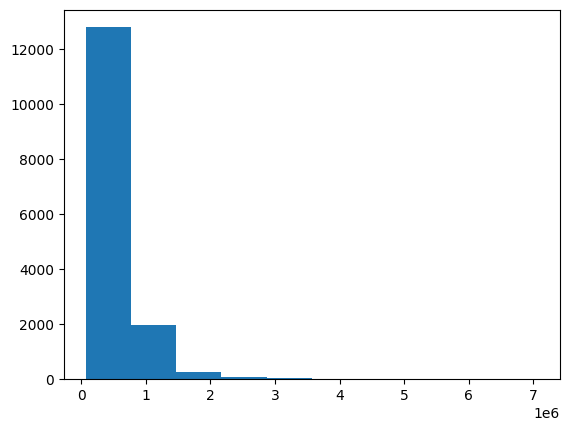

In [6]:
## 종속변수의 분포 확인
plt.hist(train['price'])
plt.show()

In [7]:
## 1) Stepwise Regression
X_train = train.drop(columns=['price'])
y_train = train['price']
X_test = test.drop(columns=['price'])
y_test = test['price']


In [11]:
## 데이터 표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = scaler.transform(X_test) ## X_train의 평균, 표준편차로 표준화!!!
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


# 기본 모델

In [12]:
## 모든 변수를 이용한 full model
lm_full = sm.OLS(y_train, sm.add_constant(X_train_scaled)).fit()

## 변수가 없는 null model
lm_null = sm.OLS(y_train, sm.add_constant(pd.DataFrame(np.ones(len(y_train))))).fit()


# 단계적 선택법 적용
sfs = SFS(LinearRegression(),
          k_features='best',
          forward = False,  # 시작방향이 Full model (backward)
          floating = True,  # True이면 각 단계에서 변수를 추가하거나 제거할 때, 이전에 선택/제거된 변수들도 재고려
          scoring = 'neg_mean_squared_error',
          cv = 5,
          verbose = 2)
sfs = sfs.fit(X_train_scaled, y_train)
selected_features_step = list(sfs.k_feature_names_)


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/tsatools.py:162: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  x = pd.concat(x[::order], axis=1)

[2024-08-06 03:05:45] Features: 13/1 -- score: -45758241454.96956
[2024-08-06 03:05:50] Features: 12/1 -- score: -45758964735.52206
[2024-08-06 03:05:53] Features: 11/1 -- score: -45781225767.257034
[2024-08-06 03:05:55] Features: 10/1 -- score: -45804913150.01984
[2024-08-06 03:05:56] Features: 9/1 -- score: -45833654105.32063
[2024-08-06 03:05:59] Features: 8/1 -- score: -46028152192.858665
[2024-08-06 03:06:01] Features: 7/1 -- score: -46230923405.981
[2024-08-06 03:06:02] Features: 6/1 -- score: -46514383919.77926
[2024-08-06 03:06:03] Features: 5/1 -- score: -46969427960.75139
[2024-08-06 03:06:04] Features: 4/1 -

In [13]:
## 최종 회귀 모델
X_train_stepwise = sm.add_constant(pd.DataFrame(X_train_scaled, columns=X_train.columns)[selected_features_step])
X_test_stepwise = sm.add_constant(pd.DataFrame(X_test_scaled, columns=X_test.columns)[selected_features_step])
step_model_f = sm.OLS(y_train, X_train_stepwise).fit()


## 최종 회귀식 확인
step_model_f.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     2421.
Date:                Tue, 06 Aug 2024   Prob (F-statistic):               0.00
Time:                        03:06:05   Log-Likelihood:            -2.0710e+05
No. Observations:               15127   AIC:                         4.142e+05
Df Residuals:                   15114   BIC:                         4.143e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          5.407e+05   1737.171    311.259      0.000    5.37e+05    5.44e+05
bedrooms      -4.591e+04   2242.887    -20.469      0.000   -5.03e+04   -4.15e+04
bathrooms      3.587e+04   3047.834     11.767      0.000    2.99e+04    4.18e+04
sqft_living    9.112e+04   2015.662     45.205      0.000    8.72e+04    9.51e+04
sqft_lot       7363.0978   2530.482      2.910      0.004    2403.047    1.23e+04
condition      1.686e+04   1899.909      8.875      0.000    1.31e+04    2.06e+04
grade          1.186e+05   3185.384     37.217      0.000    1.12e+05    1.25e+05
sqft_above     8.208e+04   2083.908     39.386      0.000     7.8e+04    8.62e+04
sqft_basement  3.516e+04   1784.361     19.707      0.000    3.17e+04    3.87e+04
yr_built      -8.313e+04   2478.909    -33.536      0.000    -8.8e+04   -7.83e+04
lat            7.273e+04   1822.334     39.908      0.000    6.92e+04    7.63e+04
long          -2.421e+04   2092.536    -11.571      0.000   -2.83e+04   -2.01e+04
sqft_living15  2.419e+04   2921.473      8.281      0.000    1.85e+04    2.99e+04
sqft_lot15    -1.118e+04   2556.402     -4.375      0.000   -1.62e+04   -6172.268
==============================================================================
Omnibus:                    13628.308   Durbin-Watson:                   1.989
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1317865.607
Skew:                           3.949   Prob(JB):                         0.00
Kurtosis:                      48.039   Cond. No.                     7.13e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.43e-27. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [14]:
## test data에 적용
pred = step_model_f.predict(X_test_stepwise)

## 평가
lm_mape = mean_absolute_percentage_error(y_test, pred)
lm_rmse = mean_squared_error(y_test, pred, squared=False)

print(f'MAPE: {lm_mape}, RMSE: {lm_rmse}')

MAPE: 0.2710231965970406, RMSE: 218904.27112792694


# box-cox 변환

In [27]:
# 2) 종속변수 Box-cox 변환
pt = PowerTransformer(method='box-cox')

# Box-Cox 변환 적용 (음수가 없어야 함!!)
y_train_bc = pt.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_bc = pt.transform(y_test.values.reshape(-1, 1)).flatten()
# pt.lambdas_ = [-1/] # 지정을 원한 경우

In [28]:
print("최적 람다:", pt.lambdas_)

최적 람다: [-0.23428129]


(array([  17.,   63.,  354., 1894., 3977., 4846., 2991.,  778.,  190.,
          17.]),
 array([-4.32911576, -3.50217069, -2.67522562, -1.84828055, -1.02133548,
        -0.19439041,  0.63255466,  1.45949973,  2.2864448 ,  3.11338987,
         3.94033494]),
 <BarContainer object of 10 artists>)

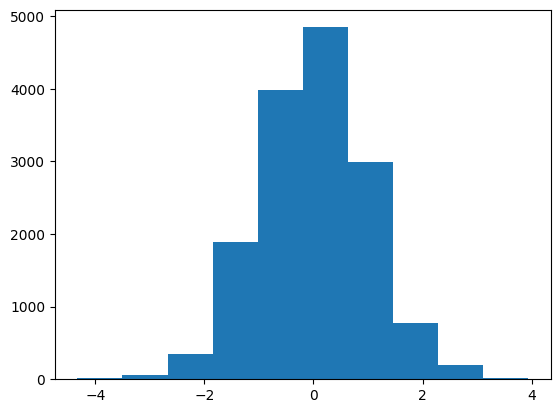

In [29]:
plt.hist(y_train_bc)

In [30]:
## 단계적 선택법 적용 (Box-Cox 변환된 데이터 사용)
sfs_trf = SFS(LinearRegression(),
              k_features = 'best',
              forward = False,
              floating = True,
              scoring = 'neg_mean_squared_error',
              cv = 5,
              verbose = 2)
sfs_trf = sfs_trf.fit(X_train_scaled, y_train_bc)
selected_features_step_trf = list(sfs_trf.k_feature_names_)



[2024-08-06 03:10:18] Features: 13/1 -- score: -0.2588961127522579
[2024-08-06 03:10:20] Features: 12/1 -- score: -0.2588961127522579
[2024-08-06 03:10:23] Features: 11/1 -- score: -0.25918714248427593
[2024-08-06 03:10:26] Features: 10/1 -- score: -0.2595855283276804
[2024-08-06 03:10:29] Features: 9/1 -- score: -0.26058914511828496
[2024-08-06 03:10:31] Features: 8/1 -- score: -0.261485987305366
[2024-08-06 03:10:33] Features: 7/1 -- score: -0.26463495767451084
[2024-08-06 03:10:34] Features: 6/1 -- score: -0.2691055573894883
[2024-08-06 03:10:36] Features: 5/1 -- score: -0.2759876273769547
[2024-08-06 03:10:37] Features: 4/1 -- score: -0.2815675974377718
[2024-08-06 03:10:38] Features: 3/1 -- score: -0.30417466115625763
[2024-08-06 03:10:38] Features: 2/1 -- score: -0.3522256210870283
[2024-08-06 03:10:39] Features: 1/1 -- score: -0.5430475116813012

In [31]:
## 최종 회귀 모델 (Box-Cox 변환된 데이터 사용)
X_train_stepwise_trf = sm.add_constant(pd.DataFrame(X_train_scaled, columns=X_train.columns)[selected_features_step_trf])
X_test_stepwise_trf = sm.add_constant(pd.DataFrame(X_test_scaled, columns=X_test.columns)[selected_features_step_trf])
step_model_trf_f = sm.OLS(y_train_bc, X_train_stepwise_trf).fit()

## 최종 회귀식 확인
step_model_trf_f.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                     3616.
Date:                Tue, 06 Aug 2024   Prob (F-statistic):               0.00
Time:                        03:10:39   Log-Likelihood:                -11226.
No. Observations:               15127   AIC:                         2.248e+04
Df Residuals:                   15114   BIC:                         2.258e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           2.49e-14      0.004   6.02e-12      1.000      -0.008       0.008
bedrooms         -0.0260      0.005     -4.883      0.000      -0.037      -0.016
bathrooms         0.1141      0.008     15.167      0.000       0.099       0.129
sqft_living       0.1180      0.005     24.619      0.000       0.109       0.127
sqft_lot          0.0351      0.004      8.120      0.000       0.027       0.044
floors            0.0874      0.006     15.042      0.000       0.076       0.099
condition         0.0808      0.005     17.817      0.000       0.072       0.090
grade             0.3574      0.008     46.960      0.000       0.343       0.372
sqft_above        0.0856      0.005     16.749      0.000       0.076       0.096
sqft_basement     0.0845      0.005     18.224      0.000       0.075       0.094
yr_built         -0.1932      0.006    -32.132      0.000      -0.205      -0.181
lat               0.3726      0.004     85.501      0.000       0.364       0.381
long             -0.0211      0.005     -4.218      0.000      -0.031      -0.011
sqft_living15     0.1577      0.007     22.560      0.000       0.144       0.171
==============================================================================
Omnibus:                      527.307   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1042.840
Skew:                          -0.255   Prob(JB):                    3.55e-227
Kurtosis:                       4.181   Cond. No.                     4.93e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 3.12e-27. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [32]:
## test data에 적용
pred_trf = step_model_trf_f.predict(X_test_stepwise_trf)

## Box-Cox 역변환(원래 단위로 역변환)
pred_trf_inv = pt.inverse_transform(np.array(pred_trf).reshape(-1, 1)).flatten()

pred_trf_inv


array([584584.51096988, 298318.47169651, 416914.88742032, ...,
       511189.42452409, 279615.69349884, 371230.34905556])

In [33]:
## 평가
lm_mape_trf = mean_absolute_percentage_error(y_test, pred_trf_inv)
lm_rmse_trf = mean_squared_error(y_test, pred_trf_inv, squared=False)

print(f'MAPE: {lm_mape_trf}, RMSE: {lm_rmse_trf}')


MAPE: 0.22848801742472974, RMSE: 3261630.2847733884


# 비교

In [34]:
## 3) 결과 비교
result = pd.DataFrame({
    'MAPE': [lm_mape, lm_mape_trf],
    'RMSE': [lm_rmse, lm_rmse_trf]
}, index=['original', 'transformed'])

result # MAPE 기준으로는 개선, RSME 기준으로는 개선되지 않음... ㅠㅠ

,MAPE,RMSE
original,0.271023,2.189043e+05
transformed,0.228488,3.261630e+06


In [35]:
# EOS